# Predicting Monthly Electricity Consumption

## Group Assignment 

### Maria Alejandra Boada Rodriguez 
### Yovanni Rojas Cardona 
### Daniel Olmedo Zapata Gaibor 
### Lisandro Daniel Rios Moya 

This notebook focuses on:
- Preparing the ENERGY STAR datasets for analysis (data cleaning).
- Exploring the data to understand patterns in monthly electricity consumption (EDA).
- Creating a clean dataset that can later be used for machine learning models.

Datasets used:
- `datasets/meter_entries.csv`
- `datasets/meters.csv`
- `datasets/properties.csv`
- `datasets/uses.csv`

## 1. Imports and basic settings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set(style="whitegrid")

## 2. Load raw datasets

In this section, we load the four CSV files provided for the project:

- `meter_entries.csv`: monthly meter readings (includes the target: electricity usage).
- `meters.csv`: information about each meter installed at the properties.
- `properties.csv`: basic characteristics of each property (size, location, etc.).
- `uses.csv`: how the floor area is distributed among different use types.

We will load them into separate pandas DataFrames for further cleaning and analysis.

In [2]:
meter_entries = pd.read_csv("meter_entries.csv")
meters = pd.read_csv("meters.csv")
properties = pd.read_csv("properties.csv")
uses = pd.read_csv("uses.csv")

## 3. Quick overview of each dataset

Here we take a first look at each dataset:
- Number of rows and columns.
- Column names.
- First few records.

This helps us understand the structure of the data before cleaning.

In [3]:
datasets = {
    "meter_entries": meter_entries,
    "meters": meters,
    "properties": properties,
    "uses": uses,
}

for name, df in datasets.items():
    print(f"{name}")
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())
    display(df.head())

meter_entries
Shape: (26222, 11)
Columns: ['Property Name', 'Portfolio Manager ID', 'Portfolio Manager Meter ID', 'Meter Name', 'Meter Type', 'Meter Consumption ID', 'Start Date', 'End Date', 'Usage/Quantity', 'Usage Units', 'Cost ($)']


,Property Name,Portfolio Manager ID,Portfolio Manager Meter ID,Meter Name,Meter Type,Meter Consumption ID,Start Date,End Date,Usage/Quantity,Usage Units,Cost ($)
0,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,8451527469,2022-01-01 00:00:00,2022-02-01 00:00:00,"42,876.27",kWh (thousand Watt-hours),5775.7
1,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,8451527470,2022-02-01 00:00:00,2022-03-01 00:00:00,"39,721.72",kWh (thousand Watt-hours),5377.67
2,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,8451527471,2022-03-01 00:00:00,2022-04-01 00:00:00,"41,278.04",kWh (thousand Watt-hours),5611
3,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,8451527472,2022-04-01 00:00:00,2022-05-01 00:00:00,"37,111.95",kWh (thousand Watt-hours),4989.06
4,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,8451527473,2022-05-01 00:00:00,2022-06-01 00:00:00,"41,778.27",kWh (thousand Watt-hours),5984.66


meters
Shape: (2585, 8)
Columns: ['Property Name', 'Portfolio Manager ID', 'Portfolio Manager Meter ID', 'Meter Name', 'Meter Type', 'Units', 'First Day of First Meter Entry', 'Last Day of Last Meter Entry']


,Property Name,Portfolio Manager ID,Portfolio Manager Meter ID,Meter Name,Meter Type,Units,First Day of First Meter Entry,Last Day of Last Meter Entry
0,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,kWh (thousand Watt-hours),2010-01-01 00:00:00,2024-09-01 00:00:00
1,#13 Police Division,35000258,189947942,AUTO_#13 Police Division-Natural Gas,Natural Gas,cm (cubic meters),2010-01-01 00:00:00,2024-09-01 00:00:00
2,#22 Police Division,35000260,189947959,AUTO_#22 Police Division-Electric,Electric - Grid,kWh (thousand Watt-hours),2010-01-01 00:00:00,2024-05-01 00:00:00
3,#22 Police Division,35000260,189947960,AUTO_#22 Police Division-Natural Gas,Natural Gas,cm (cubic meters),2010-01-01 00:00:00,2024-05-01 00:00:00
4,#23 Police Division,35000261,189947990,AUTO_#23 Police Division-Electric,Electric - Grid,kWh (thousand Watt-hours),2010-01-01 00:00:00,2024-01-01 00:00:00


properties
Shape: (1760, 8)
Columns: ['Property Name', 'Portfolio Manager ID', 'Street Address', 'City/Municipality', 'Postal Code', 'Property Type - Self-Selected', 'Gross Floor Area', 'Occupancy (%)']


,Property Name,Portfolio Manager ID,Street Address,City/Municipality,Postal Code,Property Type - Self-Selected,Gross Floor Area,Occupancy (%)
0,#11 Police Division - OLD,34999087,209 MAVETY ST,Toronto,M6P 2M1,Office,21119,100
1,#14 Police Division - OLD,34999088,150 HARRISON ST,Toronto,M6J 2A4,Office,24197,100
2,175 Memorial Park Ave,34999089,175 MEMORIAL PARK AVE,Toronto,M4J 2K5,Office,6394,100
3,18 Dyas Rd.,34999090,18 DYAS RD,North York,M3B 1V5,Office,73927,100
4,2 Civic Centre Court,34999091,2 CIVIC CENTRE CRT,Etobicoke,M9C 5A3,Office,46145,100


uses
Shape: (1760, 7)
Columns: ['Property Name', 'Portfolio Manager ID', 'Property Use Name', 'Use Type', 'Gross Floor Area for Use', 'Gross Floor Area Units', 'Gross Floor Area Temporary Value? (Y/N)']


,Property Name,Portfolio Manager ID,Property Use Name,Use Type,Gross Floor Area for Use,Gross Floor Area Units,Gross Floor Area Temporary Value? (Y/N)
0,#11 Police Division - OLD,34999087,Building Use,Office,"21,119.00",Sq. Ft.,No
1,#14 Police Division - OLD,34999088,Building Use,Office,"24,197.00",Sq. Ft.,No
2,175 Memorial Park Ave,34999089,Building Use,Office,"6,394.00",Sq. Ft.,No
3,18 Dyas Rd.,34999090,Building Use,Office,"73,927.00",Sq. Ft.,No
4,2 Civic Centre Court,34999091,Building Use,Office,"46,145.00",Sq. Ft.,No


## 4. Missing values and placeholders

Some fields may contain:
- True missing values (`NaN`).
- Text placeholders such as `"Not Available"`, `"N/A"`, `"-"`.

In this step we:
1. Inspect missing values.
2. Replace common text placeholders with real `NaN` values so they can be handled properly.

In [4]:
for name, df in datasets.items():
    print(f"{name}")
    print(df.isna().sum())

# Common placeholders to treat as missing
placeholders = ["Not Available", "NOT AVAILABLE", "N/A", "NA", "-", " "]

for name, df in datasets.items():
    datasets[name] = df.replace(placeholders, np.nan)

# Update variables
meter_entries = datasets["meter_entries"]
meters = datasets["meters"]
properties = datasets["properties"]
uses = datasets["uses"]

meter_entries
Property Name                 0
Portfolio Manager ID          0
Portfolio Manager Meter ID    0
Meter Name                    0
Meter Type                    0
Meter Consumption ID          0
Start Date                    0
End Date                      0
Usage/Quantity                0
Usage Units                   0
Cost ($)                      0
dtype: int64
meters
Property Name                     0
Portfolio Manager ID              0
Portfolio Manager Meter ID        0
Meter Name                        0
Meter Type                        0
Units                             0
First Day of First Meter Entry    0
Last Day of Last Meter Entry      0
dtype: int64
properties
Property Name                    0
Portfolio Manager ID             0
Street Address                   0
City/Municipality                0
Postal Code                      0
Property Type - Self-Selected    0
Gross Floor Area                 0
Occupancy (%)                    0
dtype: int64
uses
Prop

## 5. Data type conversion

We need to ensure:
- Date columns are stored as `datetime`.
- Numeric columns (e.g., usage, floor area, occupancy) are stored as numeric types.

This is important for correct calculations and visualisations.

In [5]:
date_cols = ["Start Date", "End Date"]
for col in date_cols:
    meter_entries[col] = pd.to_datetime(meter_entries[col], errors="coerce")

meter_entries["Usage/Quantity"] = pd.to_numeric(
    meter_entries["Usage/Quantity"], errors="coerce"
)
meter_entries["Cost ($)"] = pd.to_numeric(
    meter_entries["Cost ($)"], errors="coerce"
)

properties["Gross Floor Area"] = pd.to_numeric(
    properties["Gross Floor Area"], errors="coerce"
)
properties["Occupancy (%)"] = pd.to_numeric(
    properties["Occupancy (%)"], errors="coerce"
)

uses["Gross Floor Area for Use"] = pd.to_numeric(
    uses["Gross Floor Area for Use"], errors="coerce"
)

## 6. Remove duplicates and basic quality checks

In this step we:
- Look for duplicated rows in each dataset.
- Remove exact duplicates.
- Check for obviously invalid values (e.g., negative usage).

These operations help improve data quality before modelling.

In [6]:
for name, df in datasets.items():
    before = df.shape[0]
    df_clean = df.drop_duplicates()
    after = df_clean.shape[0]
    print(f"{name}: removed {before - after} duplicate rows")
    datasets[name] = df_clean

meter_entries = datasets["meter_entries"]
meters = datasets["meters"]
properties = datasets["properties"]
uses = datasets["uses"]

print("Negative usage values:",
      (meter_entries["Usage/Quantity"] < 0).sum())
meter_entries = meter_entries[meter_entries["Usage/Quantity"] >= 0]

meter_entries: removed 0 duplicate rows
meters: removed 0 duplicate rows
properties: removed 0 duplicate rows
uses: removed 0 duplicate rows
Negative usage values: 91


## 7. Filter Electric – Grid meter entries

Our prediction target is **monthly electricity consumption**.
Therefore, we need to keep only:

- Meter Type = `"Electric - Grid"`
- Usage Units measured in kWh.

We create a filtered dataset `electric_entries` that will be the base for modelling and EDA.

In [7]:
electric_entries = meter_entries[
    (meter_entries["Meter Type"] == "Electric - Grid")
    & (meter_entries["Usage Units"].str.contains("kWh", na=False))
].copy()

print("All entries:", meter_entries.shape[0])
print("Electric - Grid entries:", electric_entries.shape[0])

electric_entries.head()

All entries: 26131
Electric - Grid entries: 18109


,Property Name,Portfolio Manager ID,Portfolio Manager Meter ID,Meter Name,Meter Type,Meter Consumption ID,Start Date,End Date,Usage/Quantity,Usage Units,Cost ($)
0,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,8451527469,2022-01-01,2022-02-01,"42,876.27",kWh (thousand Watt-hours),"5,775.70"
1,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,8451527470,2022-02-01,2022-03-01,"39,721.72",kWh (thousand Watt-hours),"5,377.67"
2,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,8451527471,2022-03-01,2022-04-01,"41,278.04",kWh (thousand Watt-hours),"5,611.00"
3,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,8451527472,2022-04-01,2022-05-01,"37,111.95",kWh (thousand Watt-hours),"4,989.06"
4,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,8451527473,2022-05-01,2022-06-01,"41,778.27",kWh (thousand Watt-hours),"5,984.66"


## 8. Merge electricity data with property characteristics

To better understand electricity consumption, we combine:

- Monthly electric meter readings (`electric_entries`)
- Property-level information (`properties`)

We join them using the `Portfolio Manager ID`, which uniquely identifies each property.

The resulting DataFrame `electric_properties` contains both the target
(Usage/Quantity) and relevant features (floor area, occupancy, property type, etc.).

In [8]:
electric_properties = electric_entries.merge(
    properties,
    on=["Portfolio Manager ID", "Property Name"],
    how="left",
    suffixes=("", "_prop")
)

electric_properties.shape, electric_properties.head()

((18109, 17),
          Property Name  Portfolio Manager ID  Portfolio Manager Meter ID  \
 0  #13 Police Division              35000258                   189947941   
 1  #13 Police Division              35000258                   189947941   
 2  #13 Police Division              35000258                   189947941   
 3  #13 Police Division              35000258                   189947941   
 4  #13 Police Division              35000258                   189947941   
 
                           Meter Name       Meter Type  Meter Consumption ID  \
 0  AUTO_#13 Police Division-Electric  Electric - Grid            8451527469   
 1  AUTO_#13 Police Division-Electric  Electric - Grid            8451527470   
 2  AUTO_#13 Police Division-Electric  Electric - Grid            8451527471   
 3  AUTO_#13 Police Division-Electric  Electric - Grid            8451527472   
 4  AUTO_#13 Police Division-Electric  Electric - Grid            8451527473   
 
   Start Date   End Date  Usage/Quantity

## 9. Final cleaning checks

At this point, `electric_properties` is our main clean dataset.
We perform some final checks:

- Missing values in key columns.
- Basic statistics of the target (`Usage/Quantity`).
- Distribution of building size and occupancy.

This confirms the dataset is ready for Exploratory Data Analysis (EDA).

In [9]:
key_cols = [
    "Usage/Quantity",
    "Gross Floor Area",
    "Occupancy (%)",
    "Property Type - Self-Selected",
]

electric_properties[key_cols].isna().sum()

electric_properties.describe()[["Usage/Quantity", "Gross Floor Area", "Occupancy (%)"]]

,Usage/Quantity,Gross Floor Area,Occupancy (%)
count,"18,109.00","18,109.00","18,109.00"
mean,"75,976.73","17,586.80",93.80
min,0.00,1.00,0.00
25%,537.65,1.00,100.00
50%,"4,321.07",314.00,100.00
75%,"24,236.38","11,496.00",100.00
max,"11,996,753.05","986,748.00",100.00
std,"408,319.00","63,834.38",24.11


## 10. Exploratory Data Analysis (EDA)

### 10.1 Descriptive statistics

We start by computing summary statistics for the main numerical variables, including the target `Usage/Quantity`.


In [10]:
numeric_cols = ["Usage/Quantity", "Gross Floor Area", "Occupancy (%)", "Cost ($)"]
electric_properties[numeric_cols].describe()

,Usage/Quantity,Gross Floor Area,Occupancy (%),Cost ($)
count,"18,109.00","18,109.00","18,109.00","18,109.00"
mean,"75,976.73","17,586.80",93.80,"10,967.52"
std,"408,319.00","63,834.38",24.11,"55,222.95"
min,0.00,1.00,0.00,"-15,208.69"
25%,537.65,1.00,100.00,117.70
50%,"4,321.07",314.00,100.00,720.72
75%,"24,236.38","11,496.00",100.00,"3,787.69"
max,"11,996,753.05","986,748.00",100.00,"1,401,877.32"


### 10.2 Distribution of monthly electricity usage

We examine how monthly electricity consumption is distributed across all property–month observations. This helps us see if the data is skewed contains extreme values, or needs transformation.

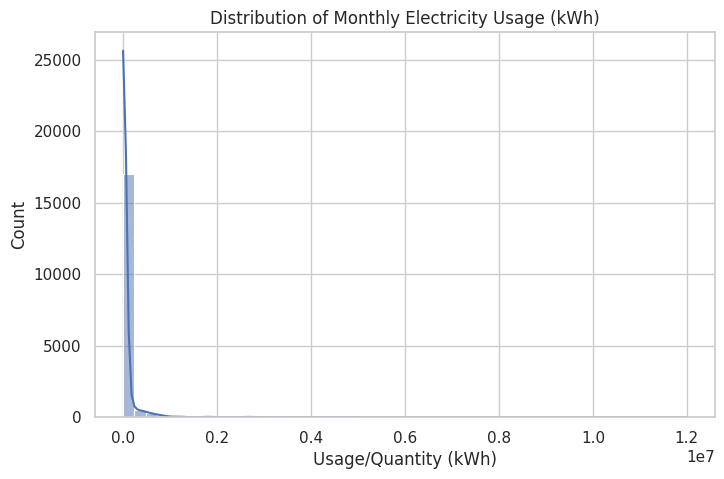

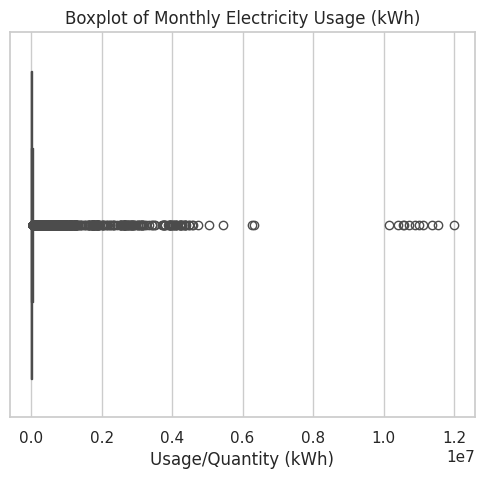

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(electric_properties["Usage/Quantity"], bins=50, kde=True)
plt.title("Distribution of Monthly Electricity Usage (kWh)")
plt.xlabel("Usage/Quantity (kWh)")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(6,5))
sns.boxplot(x=electric_properties["Usage/Quantity"])
plt.title("Boxplot of Monthly Electricity Usage (kWh)")
plt.xlabel("Usage/Quantity (kWh)")
plt.show()

### 10.3 Usage vs. building size

Here we explore how electricity consumption relates to the total gross floor area of the property. We expect larger buildings to generally consume more electricity.

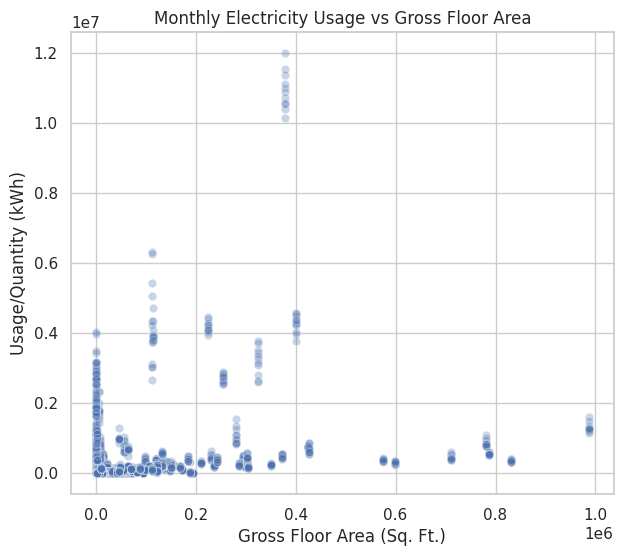

In [12]:
plt.figure(figsize=(7,6))
sns.scatterplot(
    data=electric_properties,
    x="Gross Floor Area",
    y="Usage/Quantity",
    alpha=0.3
)
plt.title("Monthly Electricity Usage vs Gross Floor Area")
plt.xlabel("Gross Floor Area (Sq. Ft.)")
plt.ylabel("Usage/Quantity (kWh)")
plt.show()

### 10.4 Usage by property type / main use

We compare the distribution of electricity usage across different property categories (self-selected type or main use). This helps identify which types of buildings tend to consume more energy.

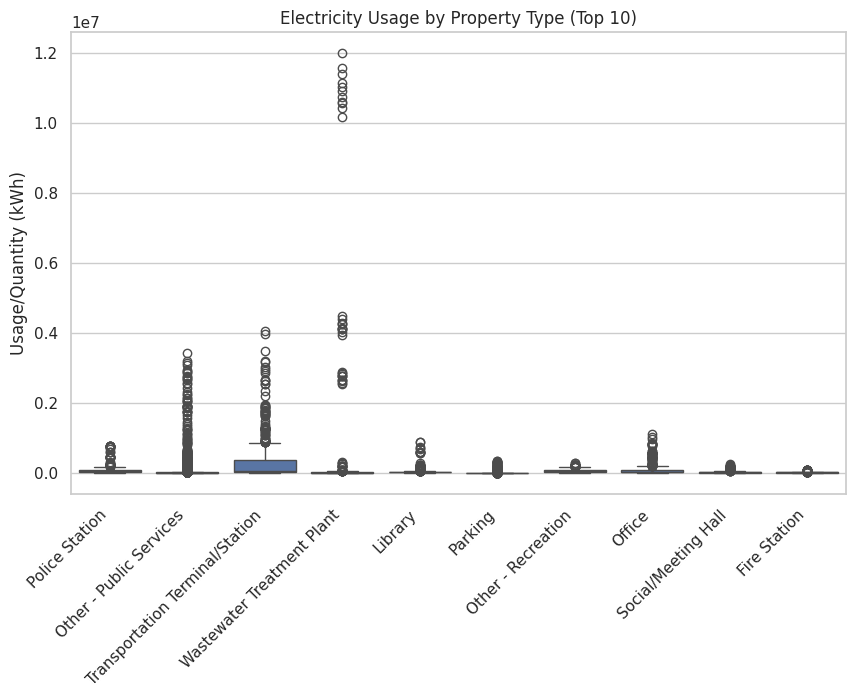

In [13]:
top_types = (
    electric_properties["Property Type - Self-Selected"]
    .value_counts()
    .head(10)
    .index
)

plt.figure(figsize=(10,6))
sns.boxplot(
    data=electric_properties[electric_properties["Property Type - Self-Selected"].isin(top_types)],
    x="Property Type - Self-Selected",
    y="Usage/Quantity"
)
plt.xticks(rotation=45, ha="right")
plt.title("Electricity Usage by Property Type (Top 10)")
plt.ylabel("Usage/Quantity (kWh)")
plt.xlabel("")
plt.show()

### 10.5 Correlation analysis

We compute a correlation matrix for the main numerical variables to identify which features are most strongly related to electricity usage.

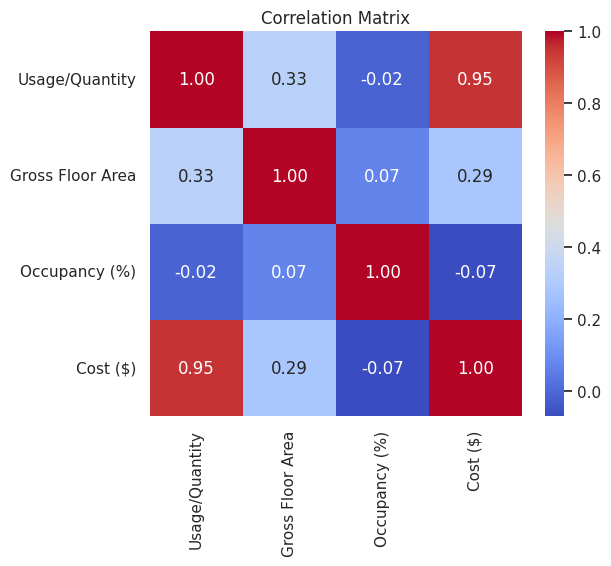

In [14]:
corr_cols = ["Usage/Quantity", "Gross Floor Area", "Occupancy (%)", "Cost ($)"]
corr = electric_properties[corr_cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

### 10.6 Monthly patterns

Finally, we look at how average electricity usage changes by month of the year. This may reveal seasonal patterns (e.g., higher usage in winter or summer).

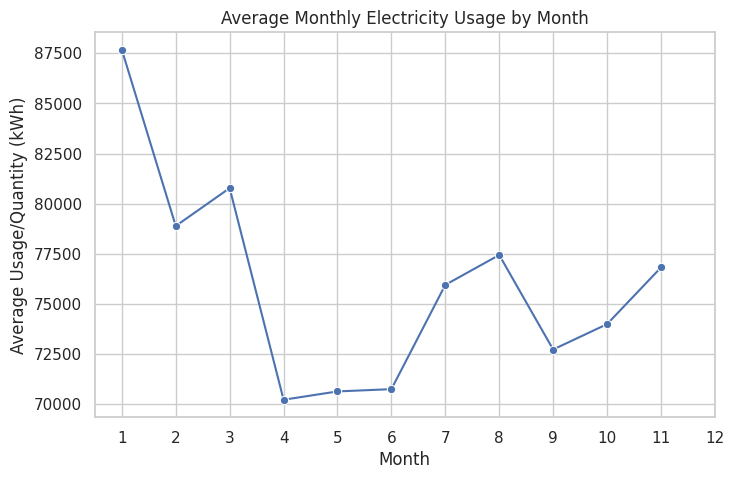

,month,Usage/Quantity
0,1,"87,683.12"
1,2,"78,881.34"
2,3,"80,773.28"
3,4,"70,203.18"
4,5,"70,619.06"
5,6,"70,732.57"
6,7,"75,940.43"
7,8,"77,433.33"
8,9,"72,712.76"
9,10,"73,978.73"


In [15]:
electric_properties["month"] = electric_properties["Start Date"].dt.month

monthly_usage = (
    electric_properties
    .groupby("month")["Usage/Quantity"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))
sns.lineplot(data=monthly_usage, x="month", y="Usage/Quantity", marker="o")
plt.title("Average Monthly Electricity Usage by Month")
plt.xlabel("Month")
plt.ylabel("Average Usage/Quantity (kWh)")
plt.xticks(range(1,13))
plt.show()

monthly_usage

## Conclusion

The four datasets were integrated, data types were standardized, and missing values or placeholders such as “Not Available” were corrected. Duplicate records and invalid entries—especially negative consumption values—were removed. We filtered only “Electric – Grid (kWh)” meters and merged property characteristics. The main issues included incomplete data, inconsistent categories, and incorrect formatting.

The EDA revealed high variability in monthly electricity consumption and the presence of outliers. We observed a positive relationship between building size and energy usage, as well as notable differences across property types. Seasonal patterns and meaningful correlations with floor area and occupancy were identified, indicating that these variables will be valuable for predicting electricity consumption.

## 11. Visualization

### 11.1 Distribution of Gross Floor Area
We examine the distribution of building sizes to identify skewness and outliers. Since floor area is a primary driver of energy consumption, understanding its structure is crucial. A highly skewed distribution (e.g., many small buildings and a few massive ones) suggest that we may need to apply a Log Transformation during the Feature Engineering stage to improve model performance. 

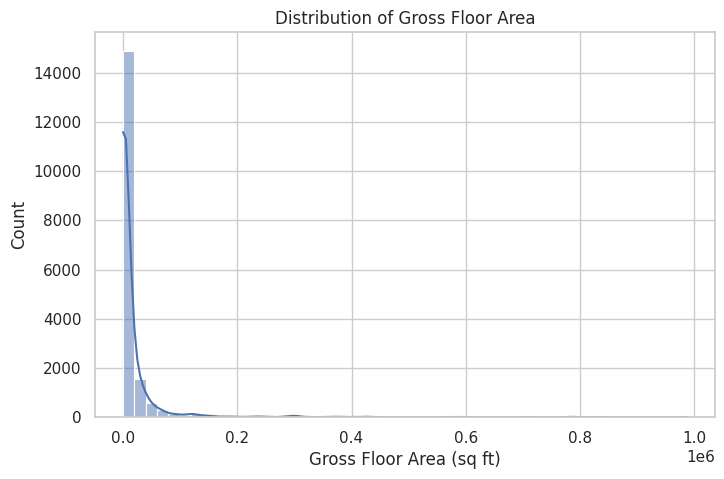

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(electric_properties["Gross Floor Area"], bins=50, kde=True)
plt.title("Distribution of Gross Floor Area")
plt.xlabel("Gross Floor Area (sq ft)")
plt.ylabel("Count")
plt.show()

### 11.2 Outlier Detection: Usage vs Cost

This scatterplot serves as a sanity check for data integrity. Since electricity costs are directly tied to consumption, we expect a strong, positive linear relationship. Any data points that deviate significatly from this diagonal trend line suggest data entry errors or billing anomalies (outliers). Identifying these ensures we do not train our model on invalid data.

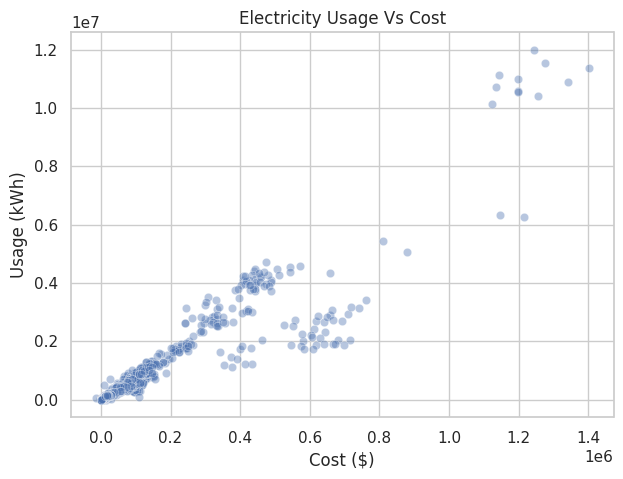

In [17]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=electric_properties,
    x="Cost ($)",
    y="Usage/Quantity",
    alpha=0.4
)
plt.title("Electricity Usage Vs Cost")
plt.xlabel("Cost ($)")
plt.ylabel("Usage (kWh)")
plt.show()

### 11.3 Average Usage per Property

We aggregate the dataset by Portfolio Manager ID to calculate the mean monthly electricity consumption for each unique building. This allows us to analyze typical usage patterns at the property level rather than individual monthly readings.

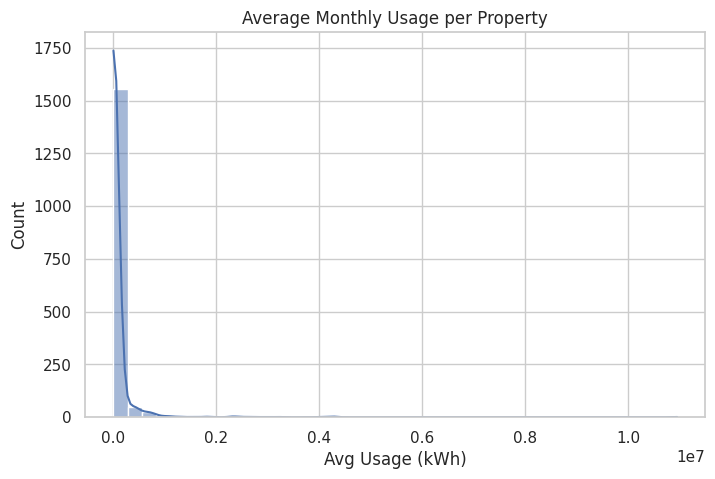

In [18]:
usage_by_property = (
    electric_properties.groupby("Portfolio Manager ID")["Usage/Quantity"].mean().reset_index()
)
plt.figure(figsize=(8,5))
sns.histplot(usage_by_property["Usage/Quantity"], bins=40, kde=True)
plt.title("Average Monthly Usage per Property")
plt.xlabel("Avg Usage (kWh)")
plt.ylabel("Count")
plt.show()

### 11.4 Usage Intensity: kWh per Square Foot

We compute Energy Intensity (Usage / Floor Area) to normalize consumption, allowing for fair efficiency comparisons between buildings of vastly different sizes. The distribution reveals true performance: while most buildings cluster at low intensity, the long tail highlights specific properties that are disproportionately energy-intensive relative to their size.

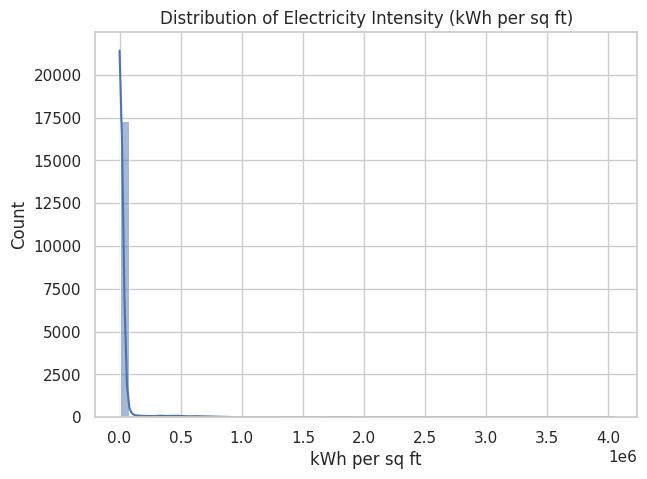

In [19]:
electric_properties["kWh_per_sqft"] = (
    electric_properties["Usage/Quantity"] /
    electric_properties["Gross Floor Area"]
)
plt.figure(figsize=(7,5))
sns.histplot(electric_properties["kWh_per_sqft"], bins=50, kde=True)
plt.title("Distribution of Electricity Intensity (kWh per sq ft)")
plt.xlabel("kWh per sq ft")
plt.ylabel("Count")
plt.show()

### 11.5 Seasonal Trend by Property Type

We aggregate average usage by Month and Property Type to visualize how different sectors respond to seasonal changes. The line chart reveals distinct behaviors: some facility types show sharp summer/winter peaks (likely due to HVAC loads), while other exhibit stable consumption profiles year-round.

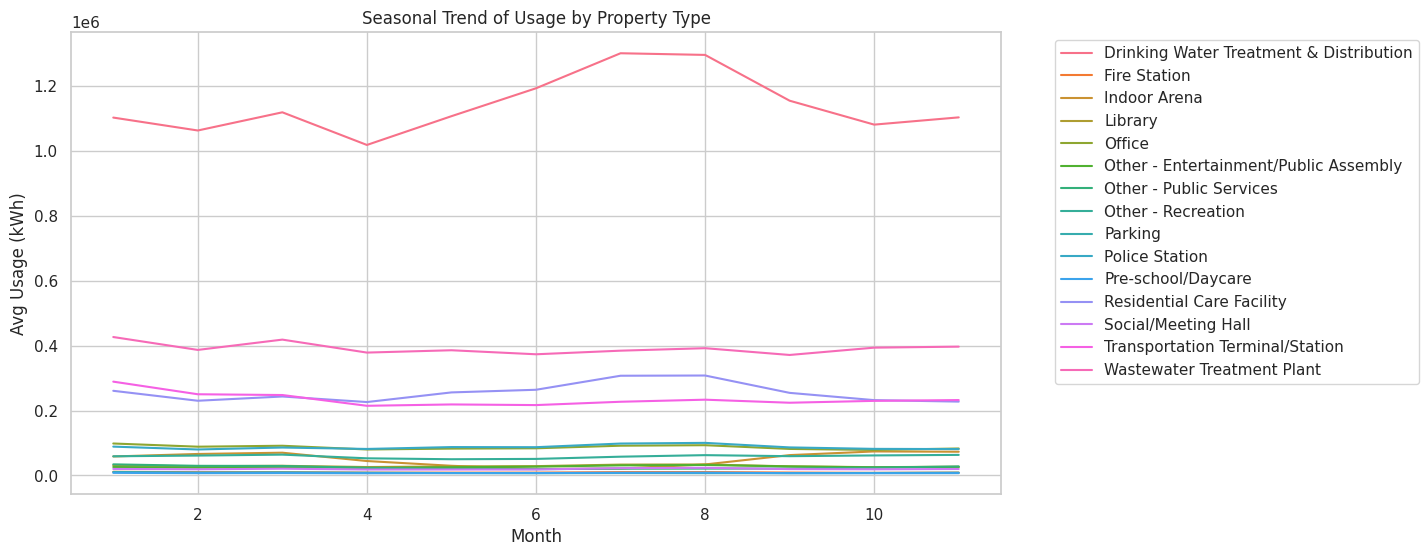

In [20]:
monthly_type_usage = (
    electric_properties.groupby(["month", "Property Type - Self-Selected"], observed=True)["Usage/Quantity"].mean().reset_index()
)
plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_type_usage, x="month", y="Usage/Quantity", hue="Property Type - Self-Selected"
)
plt.title("Seasonal Trend of Usage by Property Type")
plt.xlabel("Month")
plt.ylabel("Avg Usage (kWh)")
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.show()


## 12. Feature Engineering (revised)

> **What changed in this version.** The first version of this notebook reported R² ≈ 0.99, but that result came from **data leakage**: several features were calculated from the target itself.
>
> | Removed feature | Why it leaked |
> |---|---|
> | `kWh_per_sqft` | = **usage** ÷ floor area. Knowing it plus floor area gives the exact answer. |
> | `usage_per_occupancy` | = **usage** ÷ occupancy. Same problem. |
> | `prop_avg/std/min/max_usage` | Each building's usage statistics were computed over **all** months, including the months the model was tested on. |
>
> On its own, `kWh_per_sqft` plus floor area reached R² = 0.986, which confirmed the leak.
>
> The revised features only use information that would be available **before** the month being predicted: building characteristics, the calendar, and the building's usage in *previous* months. The train/test split is also now **time-based**, so the model is always tested on months after the ones it learned from.

### 12.1 Time-based features

Month and season flags capture heating and cooling demand. (The data covers January–November 2022, so there is one year only and no `year` feature.)

In [21]:
model_df = electric_properties.copy()

# Drop the EDA-only intensity column so it can't be used as a feature by mistake
model_df = model_df.drop(columns=["kWh_per_sqft"], errors="ignore")

model_df["month"] = model_df["Start Date"].dt.month
model_df["is_winter"] = model_df["month"].isin([12, 1, 2]).astype(int)
model_df["is_summer"] = model_df["month"].isin([6, 7, 8]).astype(int)

print("Date range:", model_df["Start Date"].min().date(), "to", model_df["Start Date"].max().date())
model_df[["Start Date", "month", "is_winter", "is_summer"]].head()

Date range: 2022-01-01 to 2022-11-01


,Start Date,month,is_winter,is_summer
0,2022-01-01,1,1,0
1,2022-02-01,2,1,0
2,2022-03-01,3,0,0
3,2022-04-01,4,0,0
4,2022-05-01,5,0,0


### 12.2 Lag features (usage in previous months)

For each meter, we look **backwards only**:
- `lag_1`: usage in the previous month
- `lag_2`: usage two months ago
- `rolling_3`: average of the previous three months

`shift(1)` makes sure the current month's usage is never included. The first months of each meter have no history, so these values are missing and get imputed later.

In [22]:
model_df = model_df.sort_values(["Portfolio Manager Meter ID", "Start Date"]).reset_index(drop=True)
usage_by_meter = model_df.groupby("Portfolio Manager Meter ID")["Usage/Quantity"]

model_df["lag_1"] = usage_by_meter.shift(1)
model_df["lag_2"] = usage_by_meter.shift(2)
model_df["rolling_3"] = usage_by_meter.transform(lambda s: s.shift(1).rolling(3, min_periods=1).mean())

model_df[["Portfolio Manager Meter ID", "Start Date", "Usage/Quantity", "lag_1", "lag_2", "rolling_3"]].head(6)

,Portfolio Manager Meter ID,Start Date,Usage/Quantity,lag_1,lag_2,rolling_3
0,189947870,2022-01-01,"81,354.77",NaN,NaN,NaN
1,189947870,2022-02-01,"73,341.16","81,354.77",NaN,"81,354.77"
2,189947870,2022-03-01,"74,004.70","73,341.16","81,354.77","77,347.96"
3,189947870,2022-04-01,"78,411.08","74,004.70","73,341.16","76,233.54"
4,189947870,2022-05-01,"91,312.13","78,411.08","74,004.70","75,252.31"
5,189947870,2022-06-01,"85,844.94","91,312.13","78,411.08","81,242.64"


### 12.3 Time-based train/test split

Instead of a random split, we train on **January–August** and test on **September–November**. This mirrors real forecasting: the model never sees the future during training.

In [23]:
SPLIT_DATE = "2022-09-01"
train_mask = model_df["Start Date"] < SPLIT_DATE

print(f"Training rows: {train_mask.sum():,} (Jan–Aug)")
print(f"Test rows:     {(~train_mask).sum():,} (Sep–Nov)")

Training rows: 13,176 (Jan–Aug)
Test rows:     4,933 (Sep–Nov)


### 12.4 Encoding and feature list

Property type is one-hot encoded. The feature list is written out explicitly so it's easy to check that nothing is derived from the target.

In [24]:
encoded_df = pd.get_dummies(
    model_df,
    columns=["Property Type - Self-Selected"],
    drop_first=True,
    dtype=int,
)

TARGET = "Usage/Quantity"
base_features = ["Gross Floor Area", "Occupancy (%)", "month", "is_winter", "is_summer"]
lag_features = ["lag_1", "lag_2", "rolling_3"]
type_features = [c for c in encoded_df.columns if c.startswith("Property Type - Self-Selected_")]

FEATURES = base_features + lag_features + type_features
print(f"{len(FEATURES)} features: {base_features + lag_features} + {len(type_features)} property-type dummies")

X_train = encoded_df.loc[train_mask, FEATURES]
X_test = encoded_df.loc[~train_mask, FEATURES]
y_train = encoded_df.loc[train_mask, TARGET]
y_test = encoded_df.loc[~train_mask, TARGET]

22 features: ['Gross Floor Area', 'Occupancy (%)', 'month', 'is_winter', 'is_summer', 'lag_1', 'lag_2', 'rolling_3'] + 14 property-type dummies


## 13. Model Building

Imputation and scaling are wrapped in a **Pipeline**, so they are fitted on the training months only and then applied to the test months. In the first version the scaler was fitted on the full dataset, which is another, smaller form of leakage.

### 13.1 Naive baseline

Before training anything, we check a simple rule: *"this month will be the same as last month."* A model is only useful if it beats this.

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(y_true, y_pred, model_name):
    return pd.Series({
        "MAE (kWh)": mean_absolute_error(y_true, y_pred),
        "RMSE (kWh)": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R^2": r2_score(y_true, y_pred),
    }, name=model_name)

# Baseline: last month's usage (fall back to the training median when there is no history)
baseline_pred = X_test["lag_1"].fillna(y_train.median())
eval_baseline = evaluate_model(y_test, baseline_pred, "Baseline (last month)")
eval_baseline

MAE (kWh)     8,155.95
RMSE (kWh)   42,574.16
R^2               0.99
Name: Baseline (last month), dtype: float64

### 13.2 Model 1: Ridge Regression

Ridge regression is a linear model with L2 regularization, which shrinks coefficients and keeps them stable when features are correlated (the three lag features are). It serves as an interpretable baseline.

In [26]:
ridge_model = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
    ("model", Ridge(random_state=42)),
])
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

### 13.3 Model 2: Random Forest Regressor

Random forests capture non-linear relationships and interactions, and they are fairly robust to the outliers seen in the EDA. Hyperparameters are tuned with `GridSearchCV` using **`TimeSeriesSplit`**, so each validation fold is also later in time than its training data.

In [27]:
# TimeSeriesSplit needs the training rows in chronological order
order = encoded_df.loc[train_mask, "Start Date"].argsort().values
X_train_sorted = X_train.iloc[order]
y_train_sorted = y_train.iloc[order]

rf_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1)),
])

param_grid = {
    "model__n_estimators": [50, 100],
    "model__max_depth": [5, 10],
    "model__min_samples_leaf": [5, 10],
}

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=TimeSeriesSplit(n_splits=3),
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
)
grid_search.fit(X_train_sorted, y_train_sorted)

best_rf_model = grid_search.best_estimator_
y_pred_rf = best_rf_model.predict(X_test)
print("Best parameters:", grid_search.best_params_)

Best parameters: {'model__max_depth': 10, 'model__min_samples_leaf': 5, 'model__n_estimators': 100}


## 14. Model Evaluation

### 14.1 Compare models

In [28]:
eval_ridge = evaluate_model(y_test, y_pred_ridge, "Ridge Regression")
eval_rf = evaluate_model(y_test, y_pred_rf, "Random Forest")

evaluation_df = pd.concat([eval_baseline, eval_ridge, eval_rf], axis=1)
evaluation_df.round(3)

,Baseline (last month),Ridge Regression,Random Forest
MAE (kWh),"8,155.95","65,217.99","10,405.42"
RMSE (kWh),"42,574.16","79,113.48","64,322.91"
R^2,0.99,0.96,0.97


### 14.2 Residual analysis (Random Forest)

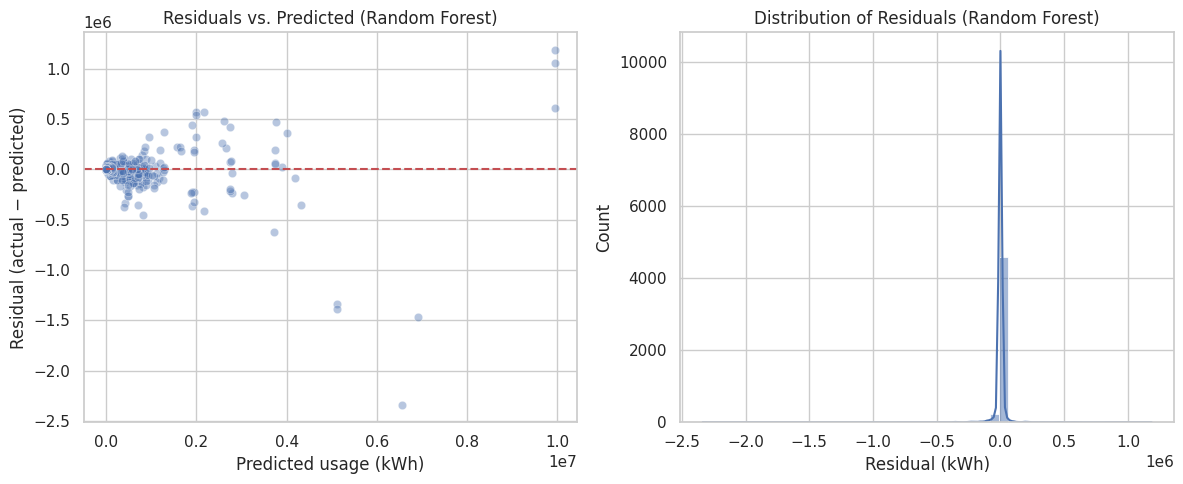

In [29]:
residuals = y_test - y_pred_rf

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_pred_rf, y=residuals, alpha=0.4)
plt.axhline(y=0, color="r", linestyle="--")
plt.title("Residuals vs. Predicted (Random Forest)")
plt.xlabel("Predicted usage (kWh)")
plt.ylabel("Residual (actual − predicted)")

plt.subplot(1, 2, 2)
sns.histplot(residuals, bins=50, kde=True)
plt.title("Distribution of Residuals (Random Forest)")
plt.xlabel("Residual (kWh)")

plt.tight_layout()
plt.show()

### 14.3 Feature importance

Which inputs does the Random Forest rely on most?

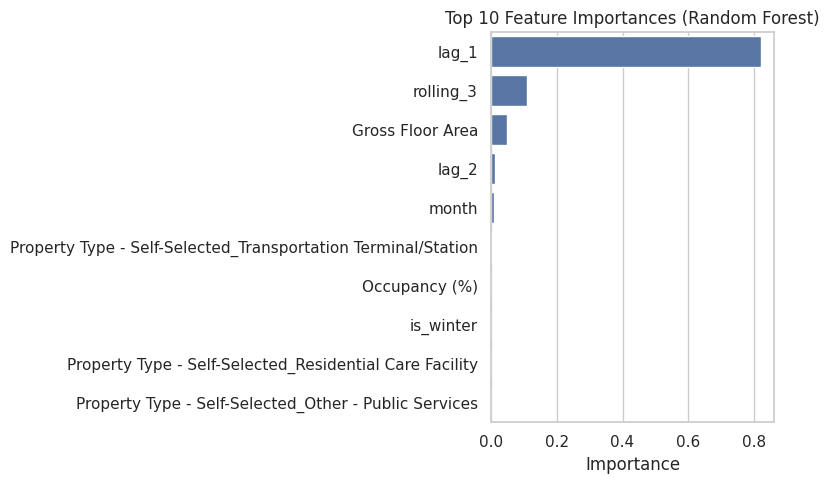

lag_1                                                           0.82
rolling_3                                                       0.11
Gross Floor Area                                                0.05
lag_2                                                           0.01
month                                                           0.01
Property Type - Self-Selected_Transportation Terminal/Station   0.00
Occupancy (%)                                                   0.00
is_winter                                                       0.00
Property Type - Self-Selected_Residential Care Facility         0.00
Property Type - Self-Selected_Other - Public Services           0.00
dtype: float64

In [30]:
importances = pd.Series(
    best_rf_model.named_steps["model"].feature_importances_,
    index=FEATURES,
).sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

importances.round(3)

### 14.4 How much does usage history matter?

To check how much of the performance comes from past usage, we retrain the Random Forest **without** the lag features, using building characteristics and season only.

In [31]:
no_history_features = base_features + type_features

rf_no_history = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1, **{
        k.replace("model__", ""): v for k, v in grid_search.best_params_.items()
    })),
])
rf_no_history.fit(X_train[no_history_features], y_train)
y_pred_no_history = rf_no_history.predict(X_test[no_history_features])

comparison = pd.concat([
    evaluate_model(y_test, y_pred_no_history, "RF – building + season only"),
    eval_rf.rename("RF – with usage history"),
], axis=1)
comparison.round(3)

,RF – building + season only,RF – with usage history
MAE (kWh),"54,612.66","10,405.42"
RMSE (kWh),"184,475.02","64,322.91"
R^2,0.79,0.97


### 14.5 Can a model beat "same as last month"?

The Random Forest above does **not** beat the naive baseline. One common fix is to predict the **change** from last month instead of the raw usage, then add it back to last month's value. We try it with a log-ratio target, so changes are measured in percent and large buildings don't dominate.

In [32]:
has_history = encoded_df["lag_1"].fillna(0) > 0
train_rows = train_mask & has_history & (encoded_df[TARGET] > 0)

# Target: log of (this month / last month)
y_change = np.log1p(encoded_df[TARGET]) - np.log1p(encoded_df["lag_1"])

rf_change = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_leaf=5,
                                    random_state=42, n_jobs=-1)),
])
rf_change.fit(encoded_df.loc[train_rows, FEATURES], y_change[train_rows])

# Convert predicted % change back to kWh; rows without history keep the baseline value
y_pred_change = baseline_pred.copy()
test_has_history = has_history[~train_mask].values
y_pred_change[test_has_history] = np.expm1(
    np.log1p(X_test.loc[test_has_history, "lag_1"])
    + rf_change.predict(X_test.loc[test_has_history, FEATURES])
)

final_comparison = pd.concat([
    eval_baseline,
    eval_rf,
    evaluate_model(y_test, y_pred_change, "RF – predicting % change"),
], axis=1)
final_comparison.round(3)

,Baseline (last month),Random Forest,RF – predicting % change
MAE (kWh),"8,155.95","10,405.42","8,582.12"
RMSE (kWh),"42,574.16","64,322.91","43,674.44"
R^2,0.99,0.97,0.99


## 15. Conclusion

**Test period: September–November 2022 (4,933 property-months the models never saw).**

| Approach | MAE (kWh) | R² |
|---|---|---|
| Original notebook (with data leakage) | 4,349 | 0.99 ❌ not valid |
| Random Forest, building + season only | ~54,600 | 0.79 |
| Random Forest, with usage history | ~10,400 | 0.97 |
| RF predicting % change | ~8,600 | 0.988 |
| **Naive baseline: "same as last month"** | **~8,150** | **0.989** |

**Key findings**

1. **The original 0.99 was leakage.** Once features built from the target were removed, a properly tested model scores lower, but the score can be trusted.
2. **Past usage is everything.** `lag_1` alone accounts for over 80% of the Random Forest's feature importance. Without usage history, R² falls from 0.97 to 0.79.
3. **No model beat the naive baseline.** Monthly electricity use in these facilities is very stable, so "same as last month" is extremely hard to beat. Month-to-month changes are small and mostly noise that size, type and season can't explain.
4. **The RMSE is much larger than the MAE**, so a handful of very large facilities cause most of the big errors.

**What would actually improve the forecast**

- **More history.** With only 11 months of data, the model can't learn yearly seasonality. Two or more years would allow a "same month last year" feature.
- **Weather data.** Heating and cooling degree-days explain most month-to-month swings in building energy use.
- **Separate treatment for the largest facilities**, which drive most of the error.

**Lesson learned:** always compare a model against a simple baseline, and check that every feature would be available *at prediction time*. The original R² of 0.99 looked impressive, but the honest answer is that, with this data, a simple rule is as good as machine learning.